## 🌲 Evaluating Random Forest Performance

---

## 🎯 Objectives

After completing this lab, I will be able to:

- 🌲 Implement and evaluate a **Random Forest regression model** on real-world data  
- 📊 Interpret evaluation metrics and visualizations  
- 🧠 Analyze **feature importances** in a regression context  

---

## 📚 Introduction

In this lab, I explore how to evaluate a regression model using real-world housing data 🏡

- 📍 Dataset: **California Housing (scikit-learn)**  
- 🎯 Task: Predict the **median house price** based on various features  

---

## 🛠️ What is covered

- 🌲 Build a **Random Forest Regressor**  
- 📊 Evaluate model performance using regression metrics  
- 📈 Visualize predictions and model behavior  
- 🧠 Examine feature importance to understand key drivers  

---

## 🧠 Key Idea

The goal is not to find the best model, but to:

- 🔍 Interpret model outputs and performance  
- ⚖️ Understand how features influence predictions  
- 📊 Gain intuition about regression evaluation  

---

## 📦 Load Libraries

I begin by ensuring all required libraries are available 🚀

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import skew

## 📥 Load the California Housing Dataset

I load the **California Housing dataset** from `scikit-learn`, which contains information about housing districts and their corresponding median house values.

In [4]:
# Load the dataset
data = fetch_california_housing()
X, y = data.data, data.target

## 📄 Dataset Description

I print the full description of the **California Housing dataset** to better understand its features, target variable, and overall structure.

In [5]:
print(data.DESCR)  # Print the dataset description

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [6]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 🔍 Explore the Training Data

I explore the **training dataset** to understand its structure, distributions, and basic statistics before building the model.

In [7]:
eda = pd.DataFrame(data=X_train) # Create a DataFrame for EDA
eda.columns = data.feature_names # Set the column names to the feature names
eda['MedHouseVal'] = y_train # Add the target variable to the DataFrame
eda.describe() # Get summary statistics of the training data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.880754,28.608285,5.435235,1.096685,1426.453004,3.096961,35.643149,-119.582290,2.071947
std,1.904294,12.602499,2.387375,0.433215,1137.056380,11.578744,2.136665,2.005654,1.156226
min,0.499900,1.000000,0.888889,0.333333,3.000000,0.692308,32.550000,-124.350000,0.149990
25%,2.566700,18.000000,4.452055,1.006508,789.000000,2.428799,33.930000,-121.810000,1.198000
50%,3.545800,29.000000,5.235874,1.049286,1167.000000,2.817240,34.260000,-118.510000,1.798500
75%,4.773175,37.000000,6.061037,1.100348,1726.000000,3.280000,37.720000,-118.010000,2.651250
max,15.000100,52.000000,141.909091,25.636364,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 📊 Exercise 2: Range of Median House Prices

Considering the **25th to 75th percentile (interquartile range)**, most median house prices fall between:

- 💰 **$119,300 and $265,000**

---

## 🧠 Interpretation

- 📊 This range captures the **middle 50%** of the data  
- 🏡 Indicates that most properties are moderately priced  
- 📉 Helps reduce the impact of extreme values (outliers)  

## 📊 Distribution of Median House Prices

The distribution is **right-skewed**, with a noticeable number of values **clipped around $500,000**, indicating an upper limit in the dataset.

Text(0, 0.5, 'Frequency')

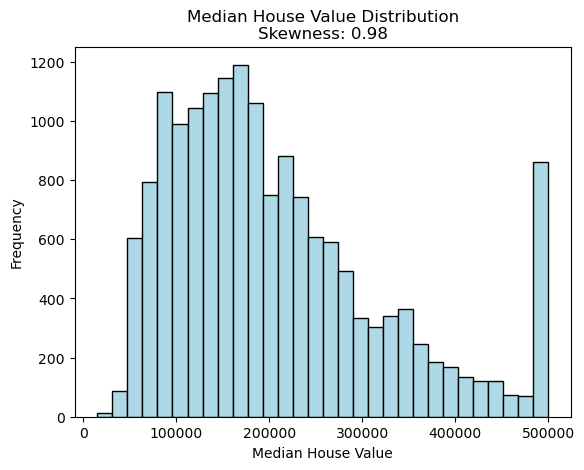

In [8]:
# Plot the distribution
plt.hist(1e5*y_train, bins=30, color='lightblue', edgecolor='black')
plt.title(f'Median House Value Distribution\nSkewness: {skew(y_train):.2f}')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')

## 🌲 Model Fitting and Prediction

A **Random Forest Regressor** is fitted to the training data and used to predict median house prices. The model is initialized with default parameters, including **100 decision trees (estimators)**.

In [9]:
# Initialize and fit the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

# Predict on test set
y_pred_test = rf_regressor.predict(X_test)

## 📊 Out-of-Sample Evaluation Metrics

The performance of the Random Forest model is evaluated on the **test set** using common regression metrics: MAE, MSE, RMSE, and R².

In [10]:
mae = mean_absolute_error(y_test, y_pred_test) # Calculate Mean Absolute Error (MAE)
mse = mean_squared_error(y_test, y_pred_test) # Calculate Mean Squared Error (MSE)
rmse = root_mean_squared_error(y_test, y_pred_test) # Calculate Root Mean Squared Error (RMSE)
r2 = r2_score(y_test, y_pred_test) # Calculate R² Score
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.3276
Mean Squared Error (MSE): 0.2557
Root Mean Squared Error (RMSE): 0.5057
R² Score: 0.8049


## 🧠 Interpretation of Results

The **Mean Absolute Error (MAE)** is approximately **$33,220**.

This means that, on average, predicted median house prices differ from the actual values by about **$33k**.

---

The **Mean Squared Error (MSE)** is less intuitive to interpret directly, but it is typically what the model minimizes during training.

Taking the square root of MSE gives the **Root Mean Squared Error (RMSE)**, which is expressed in dollar units. Here, **RMSE ≈ $50,630**, meaning typical errors are around this magnitude, with larger errors penalized more heavily.

---

The **R² score is 0.80**, which indicates that approximately **80% of the variance** in median house prices is explained by the model.

However, this interpretation can be misleading for complex datasets that include nonlinear relationships, skewed distributions, and outliers. Despite this, R² remains useful for **comparing different models**.

---

## 🧾 Conclusion

These statistics alone do not fully describe model performance. They do not show:

- 📍 Where the model performs well  
- 📍 Where it performs poorly  
- 📍 Whether errors are concentrated in specific regions or price ranges  

---

## 🚀 Next Step

Further analysis is needed to better understand model behavior across different parts of the dataset.

## 📈 Actual vs Predicted Values

I compare the **actual median house prices** with the **predicted values** from the Random Forest model to visually assess model performance.

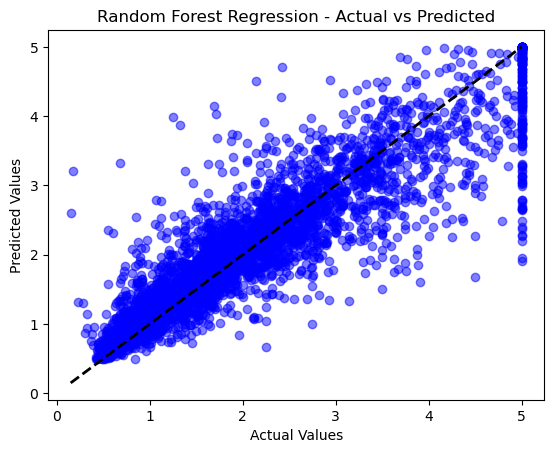

In [11]:
plt.scatter(y_test, y_pred_test, alpha=0.5, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regression - Actual vs Predicted")
plt.show()

## 📊 Exercise 4: Residual Error Analysis

Residual errors are computed as the difference between **actual values** and **predicted values**, expressed in dollars. These errors are analyzed using a histogram along with summary statistics.

Average error = -1216
Standard deviation of error = 50554


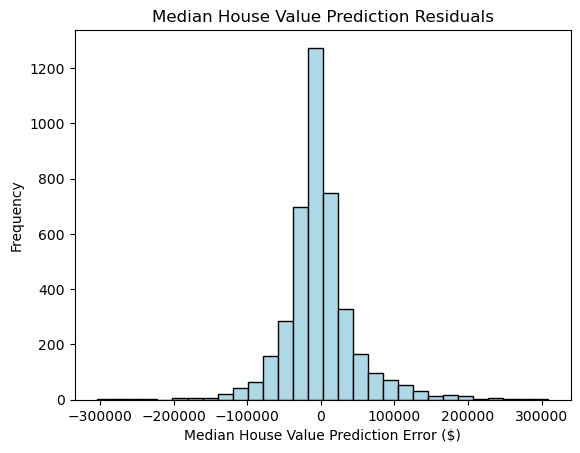

In [14]:
# plot the histogram of residuals error (dollar value)
residuals = 1e5*(y_test - y_pred_test)

plt.hist(residuals, bins=30, color='lightblue', edgecolor='black')
plt.title(f'Median House Value Prediction Residuals')
plt.xlabel('Median House Value Prediction Error ($)')
plt.ylabel('Frequency')
print('Average error = ' + str(int(np.mean(residuals))))
print('Standard deviation of error = ' + str(int(np.std(residuals))))

## 📊 Residual Error Analysis

The residuals are approximately **normally distributed**, with a mean close to **0**, indicating little systematic bias in the predictions.

The standard deviation of the residuals is about **$50,000**, meaning typical prediction errors vary around this range.

---

## 🧠 Interpretation

- 📉 Mean residual ≈ 0 → predictions are generally unbiased  
- 📊 Normal-shaped distribution → errors are fairly symmetric  
- 💰 Standard deviation ≈ $50,000 → typical deviation from actual prices  

---

## 📊 Exercise 5: Residual Errors vs Median House Value

Residual errors are plotted against the **actual median house values**, after sorting the data. This helps identify whether prediction errors depend on house price levels.


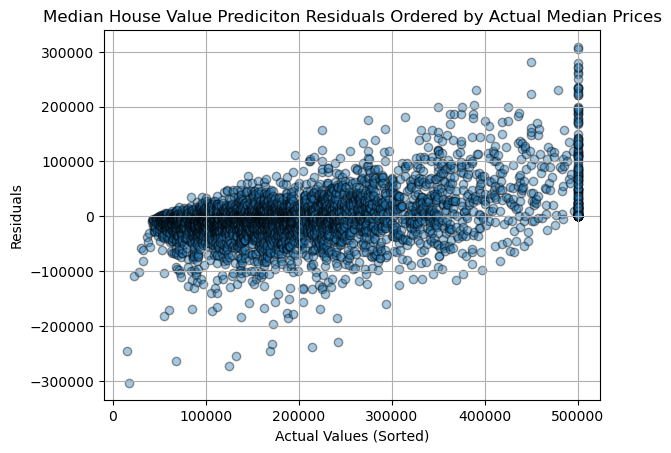

In [16]:
# Sort the residuals by actual median house value before plotting the residuals.
    
# Create a DataFrame to make sorting easy
residuals_df = pd.DataFrame({
    'Actual': 1e5*y_test,
    'Residuals': residuals
})

# Sort the DataFrame by the actual target values
residuals_df = residuals_df.sort_values(by='Actual')

# Plot the residuals
plt.scatter(residuals_df['Actual'], residuals_df['Residuals'], marker='o', alpha=0.4,ec='k')
plt.title('Median House Value Prediciton Residuals Ordered by Actual Median Prices')
plt.xlabel('Actual Values (Sorted)')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

## 📊 Exercise 6: Trend in Residual Errors

From the residual plot, a clear trend emerges in how prediction errors vary with median house value.

---

## 🧠 Observed Trend

Although the **average residual is small (around -$1,400)**, the error is not constant across all price levels.

- 📉 At **lower median house values**, residuals tend to be **positive**
  → the model **overpredicts** cheaper houses  

- 📈 At **higher median house values**, residuals tend to be **negative**
  → the model **underpredicts** expensive houses  

---

## 📊 Interpretation

- ⚖️ The model is biased toward the mean of the distribution  
- 🏡 It struggles to fully capture extreme values (very cheap or very expensive homes)  
- 📉 This creates a systematic pattern in residuals rather than random noise  

---

## 🧠 Conclusion

The residual plot reveals a **structured error pattern**, indicating that the model is not perfectly capturing nonlinear effects in the relationship between features and house prices.  

## 🌲 Exercise 7: Feature Importances

The feature importances from the Random Forest model are visualized using a bar chart to understand which variables contribute most to predicting median house values.

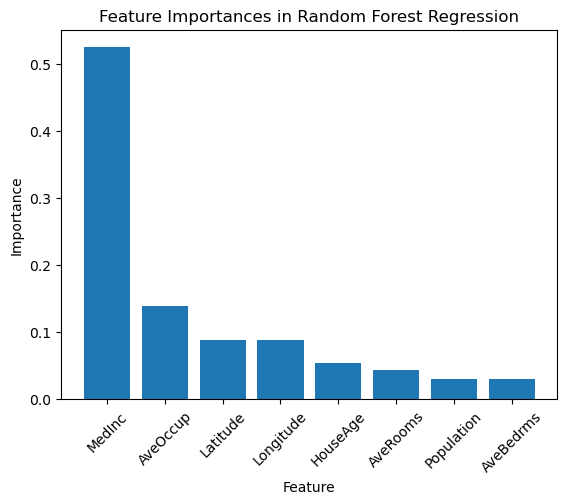

In [17]:
# Feature importances
importances = rf_regressor.feature_importances_
indices = np.argsort(importances)[::-1]
features = data.feature_names

# Plot feature importances
plt.bar(range(X.shape[1]), importances[indices],  align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest Regression")
plt.show()

## 🧠 Interpretation of Feature Importances

It is expected that **median income** shows the highest importance, since income levels are strongly correlated with **house prices**.

---

## 📍 Role of Location

Location is likely a major driver of housing prices:

- 🌐 **Latitude and longitude** each contribute separately to the model  
- 🗺️ Their similar importance suggests they jointly capture a **strong location effect**  
- 📊 If combined into a single categorical variable (e.g., city or district), their **combined importance** would likely exceed several other features

---

## 🏠 Correlated Features

It is plausible that some features are correlated:

- 🛏️ **Average occupancy**
- 🏡 **Average number of bedrooms**

These variables may describe similar underlying housing characteristics, meaning:
- 🔗 Some predictive information is **shared between them**
- ⚖️ Importance may be split across correlated features rather than concentrated in one

---

## 📊 Further Analysis

A more complete understanding of feature relationships would include:

- 📉 A **correlation matrix**  
- 🔍 Investigation of multicollinearity between features  
- 🧠 Feature engineering to combine or reduce redundant variables  

---

## 🧾 Conclusion

Feature importance provides useful insight into model behavior, but correlated variables and spatial structure mean that importance values should be interpreted carefully rather than in isolation.

## 🧠 Exercise 8: Final Thoughts

---

## 📊 Skewness and Random Forest Performance

The **skewness of the target distribution** does not strongly affect Random Forest regression.

- 🌲 Random Forests are **non-parametric models**
- 📉 No assumption is made about normality or linear relationships
- ⚖️ They are generally **robust to skewed distributions and outliers**

In contrast, linear regression performs best when assumptions such as normality and linearity are satisfied.

---

## ✂️ Effect of Clipped Values (≈ $500,000)

The presence of **clipped median house values** can introduce bias:

- 🚫 No variability exists above the clipping threshold  
- 📉 This can distort the true distribution of high-value homes  
- 🧠 The model learns a **compressed representation of expensive properties**

As a result:
- 🔍 High-value predictions may be less accurate  
- 📊 Evaluation metrics may be slightly misleading  
- 🏡 The model may underestimate variation at the upper end  

---

## ⚖️ Standardization of Features

For Random Forest regression:

- ❌ Standardization is **not required**
- 🌲 Tree-based models are **scale-invariant**
- 🔍 Splits are based on thresholds, not distances

This differs from:
- 📏 KNN and SVM, where **feature scaling is essential**

---

## 🧾 Conclusion

- 🌲 Random Forest handles skewed data and outliers well  
- ✂️ Clipped target values can still bias predictions and evaluation metrics  
- 📉 Feature scaling is not necessary for this model type  
- 📊 Visualization remains essential for detecting hidden issues in the data  